In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Word Cloud
from wordcloud import WordCloud

# Counter
from collections import Counter

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Plot Style
plt.style.use('ggplot')

print("Libraries Imported Successfully 🚀")

Libraries Imported Successfully 🚀


In [2]:
# Load Cleaned Dataset
df = pd.read_csv("C:/Users/rahul/Desktop/demonetization-tweets.csv - Copy/demonetization-tweets.csv")

print("Cleaned Dataset Loaded Successfully ✅")
print("Dataset Shape:", df.shape)

Cleaned Dataset Loaded Successfully ✅
Dataset Shape: (14940, 14)


In [3]:
# Display First 5 Rows
df.head()

,Unnamed: 0,X,text,favorited,favoriteCount,created,truncated,id,statusSource,screenName,retweetCount,isRetweet,retweeted,cleaned_text
0,1,1,RT @rssurjewala: Critical question: Was PayTM ...,False,0,2016-11-23 18:40:30,False,8.014957e+17,"<a href=""http://twitter.com/download/android"" ...",HASHTAGFARZIWAL,331,True,False,critical question paytm informed demonetizatio...
1,2,2,RT @Hemant_80: Did you vote on #Demonetization...,False,0,2016-11-23 18:40:29,False,8.014957e+17,"<a href=""http://twitter.com/download/android"" ...",PRAMODKAUSHIK9,66,True,False,vote demonetization modi survey app
2,3,3,"RT @roshankar: Former FinSec, RBI Dy Governor,...",False,0,2016-11-23 18:40:03,False,8.014955e+17,"<a href=""http://twitter.com/download/android"" ...",rahulja13034944,12,True,False,former finsec rbi dy governor cbdt chair harva...
3,4,4,RT @ANI_news: Gurugram (Haryana): Post office ...,False,0,2016-11-23 18:39:59,False,8.014955e+17,"<a href=""http://twitter.com/download/android"" ...",deeptiyvd,338,True,False,gurugram haryana post office employee provide ...
4,5,5,RT @satishacharya: Reddy Wedding! @mail_today ...,False,0,2016-11-23 18:39:39,False,8.014954e+17,"<a href=""http://cpimharyana.com"" rel=""nofollow...",CPIMBadli,120,True,False,reddy wedding cartoon demonetization reddywedding


In [4]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14940 entries, 0 to 14939
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     14940 non-null  int64  
 1   X              14940 non-null  int64  
 2   text           14940 non-null  object 
 3   favorited      14940 non-null  bool   
 4   favoriteCount  14940 non-null  int64  
 5   created        14940 non-null  object 
 6   truncated      14940 non-null  bool   
 7   id             14940 non-null  float64
 8   statusSource   14940 non-null  object 
 9   screenName     14940 non-null  object 
 10  retweetCount   14940 non-null  int64  
 11  isRetweet      14940 non-null  bool   
 12  retweeted      14940 non-null  bool   
 13  cleaned_text   14912 non-null  object 
dtypes: bool(4), float64(1), int64(4), object(5)
memory usage: 1.2+ MB


## Tweet Length Analysis

Tweet length analysis helps understand the distribution of tweet sizes and textual complexity.

In [5]:
# Calculate Tweet Length

df['tweet_length'] = df['cleaned_text'].astype(str).apply(len)

print("Tweet Length Feature Created ✅")

Tweet Length Feature Created ✅


In [6]:
# Display Tweet Length Statistics

df['tweet_length'].describe()

count    14940.000000
mean        75.709505
std         19.631489
min          3.000000
25%         67.000000
50%         77.000000
75%         88.000000
max        239.000000
Name: tweet_length, dtype: float64

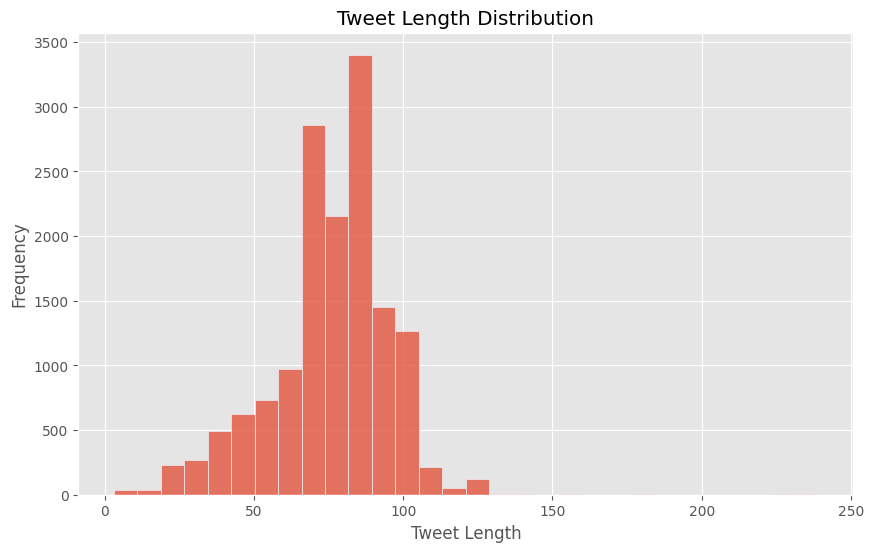

In [7]:
# Plot Tweet Length Distribution

plt.figure(figsize=(10,6))

sns.histplot(df['tweet_length'], bins=30)

plt.title("Tweet Length Distribution")
plt.xlabel("Tweet Length")
plt.ylabel("Frequency")

plt.show()

## Most Common Words

This section identifies the most frequently occurring words in cleaned tweets.

In [8]:
# Combine All Tweets

all_words = " ".join(df['cleaned_text'].astype(str))

# Tokenize Words
words = all_words.split()

# Count Word Frequency
word_freq = Counter(words)

# Display Top 20 Words
common_words = word_freq.most_common(20)

common_words

[('demonetization', 13978),
 ('india', 2983),
 ('modi', 2759),
 ('pm', 2758),
 ('narendra', 1566),
 ('rich', 1510),
 ('find', 1443),
 ('dear', 1411),
 ('implement', 1399),
 ('actually', 1374),
 ('amp', 1304),
 ('bank', 1245),
 ('people', 1231),
 ('support', 1077),
 ('r', 910),
 ('lakh', 729),
 ('impact', 704),
 ('cash', 697),
 ('terrorist', 664),
 ('jampk', 638)]

In [9]:
# Convert to DataFrame

common_words_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])

common_words_df

,Word,Frequency
0,demonetization,13978
1,india,2983
2,modi,2759
3,pm,2758
4,narendra,1566
5,rich,1510
6,find,1443
7,dear,1411
8,implement,1399
9,actually,1374


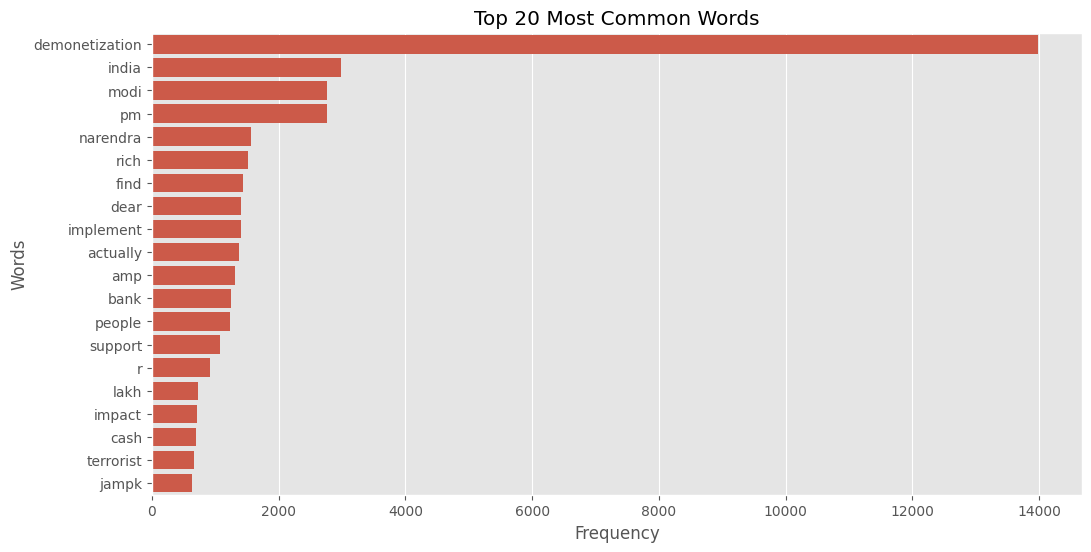

In [10]:
# Plot Most Common Words

plt.figure(figsize=(12,6))

sns.barplot(
    x='Frequency',
    y='Word',
    data=common_words_df
)

plt.title("Top 20 Most Common Words")
plt.xlabel("Frequency")
plt.ylabel("Words")

plt.show()

## Word Cloud Visualization

Word clouds visually represent the most frequent words in the dataset.

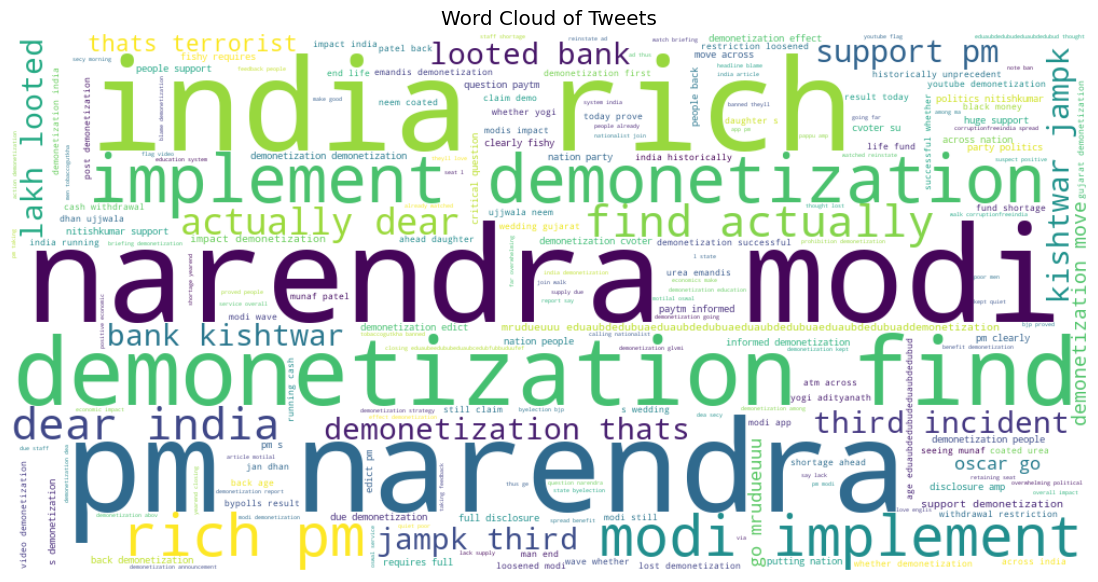

In [11]:
# Generate Word Cloud

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(all_words)

# Plot Word Cloud

plt.figure(figsize=(15,7))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title("Word Cloud of Tweets")

plt.show()

## Retweet Count Analysis

This section analyzes the distribution of retweet counts across tweets.

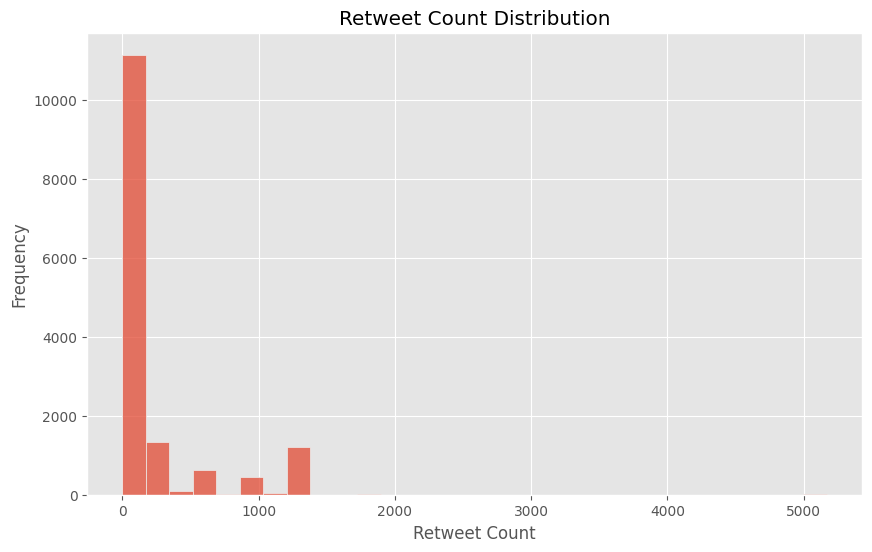

In [12]:
# Plot Retweet Count Distribution

plt.figure(figsize=(10,6))

sns.histplot(df['retweetCount'], bins=30)

plt.title("Retweet Count Distribution")
plt.xlabel("Retweet Count")
plt.ylabel("Frequency")

plt.show()